In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from scipy.stats import kurtosis

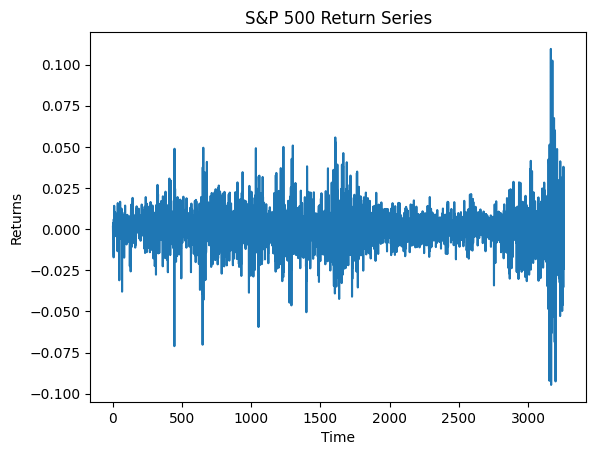

In [2]:
# Load Excel file
data = pd.read_excel("S_Pdata.xls")

# Extract return series
sp = data['SPX_r'].dropna().values

# Plot the return series
plt.plot(sp)
plt.title("S&P 500 Return Series")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.show()

In [3]:
# Descriptive statistic: Kurtosis (Biased, different from R)
print("Kurtosis:", kurtosis(sp))

Kurtosis: 8.015164243703612


In [4]:
# GARCH(1,1)
sp_scaled = sp * 100 ## R 코드에 맞춰 스케일링

model_garch = arch_model(sp_scaled, vol='GARCH', p=1, q=1, mean='Constant', dist='normal') ## 스케일링 처리 과정이 달라서 R과 수치적 차이 발생.
fit1 = model_garch.fit(disp='off')
print(fit1.summary()) ## 자동 Rescaling 기능이 없으므로 Coefficient에 1/100 곱한 것이 실제 결과.

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4844.37
Distribution:                  Normal   AIC:                           9696.74
Method:            Maximum Likelihood   BIC:                           9721.10
                                        No. Observations:                 3260
Date:                Mon, Feb 23 2026   Df Residuals:                     3259
Time:                        16:13:36   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0447  1.606e-02      2.783  5.378e-03 [1.

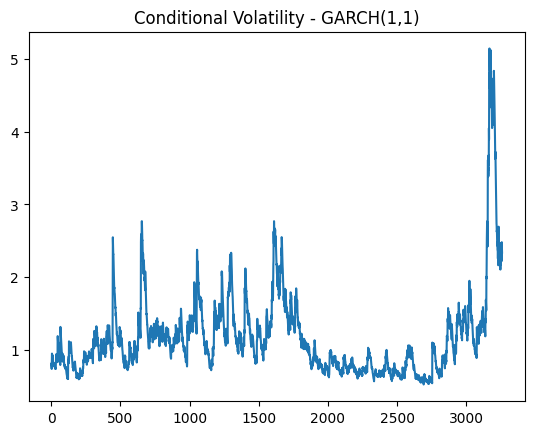

In [5]:
# Plot conditional variance
plt.plot(fit1.conditional_volatility)
plt.title("Conditional Volatility - GARCH(1,1)")
plt.show()

In [6]:
# GJR-GARCH(1,1)
model_gjr = arch_model(sp, vol='GARCH', p=1, o=1, q=1, mean='Constant', dist='normal', rescale=True)  ## 스케일링 처리 과정이 달라서 R과 수치적 차이 발생.
fit2 = model_gjr.fit(disp='off')
print(fit2.summary()) ## 자동 Rescaling 기능이 없으므로 Coefficient에 1/100 곱한 것이 실제 결과.

                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -4784.30
Distribution:                  Normal   AIC:                           9578.61
Method:            Maximum Likelihood   BIC:                           9609.06
                                        No. Observations:                 3260
Date:                Mon, Feb 23 2026   Df Residuals:                     3259
Time:                        16:13:41   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0118  1.610e-02      0.734      0.463 

In [7]:
# GARCH(1,1) with t-distributed errors
model_garch_t = arch_model(sp, vol='GARCH', p=1, q=1, mean='Constant', dist='t', rescale=True)  ## 스케일링 처리 과정이 달라서 R과 수치적 차이 발생.
fit3 = model_garch_t.fit(disp='off', cov_type='hc3')
print(fit3.summary()) ## 자동 Rescaling 기능이 없으므로 Coefficient에 1/100 곱한 것이 실제 결과.

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -4783.90
Distribution:      Standardized Student's t   AIC:                           9577.80
Method:                  Maximum Likelihood   BIC:                           9608.25
                                              No. Observations:                 3260
Date:                      Mon, Feb 23 2026   Df Residuals:                     3259
Time:                              16:15:03   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  